In [ ]:
# csv , sql, pandas analysis
#step 1 | ID | Name   | Salary |
| -- | ------ | ------ |
| 1  | Nabin  | 30000  |
| 2  | Nikhil | 45000  |
| 3  | Ram    | 50000  |
| 4  | Hari   | 35000  |
| 5  | Sita   | 60000  |


In [1]:
#step 2 csv read
import pandas as pd
df = pd.read_csv("employees.csv")
print(df)

   ID    Name  Salary
0   1   Nabin   30000
1   2  Nikhil   45000
2   3     Ram   50000
3   4    Hari   35000
4   5    Sita   60000


In [2]:
#step 3: Save to SQL
import sqlite3
conn = sqlite3.connect("employees.db")
df.to_sql("Employees", conn, if_exists="replace", index=False)
print("Saved to Database")

Saved to Database


In [3]:
# Step 4: Read from SQL
df2 = pd.read_sql_query("SELECT * FROM Employees",conn)
print(df2)

   ID    Name  Salary
0   1   Nabin   30000
1   2  Nikhil   45000
2   3     Ram   50000
3   4    Hari   35000
4   5    Sita   60000


In [5]:
# Step 5 Analysis
#Highest Salary
print("Max Salary:", df2["Salary"].max())

Max Salary: 60000


In [6]:
# Average Salary
print("Average Salary:", df["Salary"].mean())

Average Salary: 44000.0


In [8]:
#Top Salary Person
print(df.loc[df2["Salary"].idxmax()])

ID            5
Name       Sita
Salary    60000
Name: 4, dtype: object


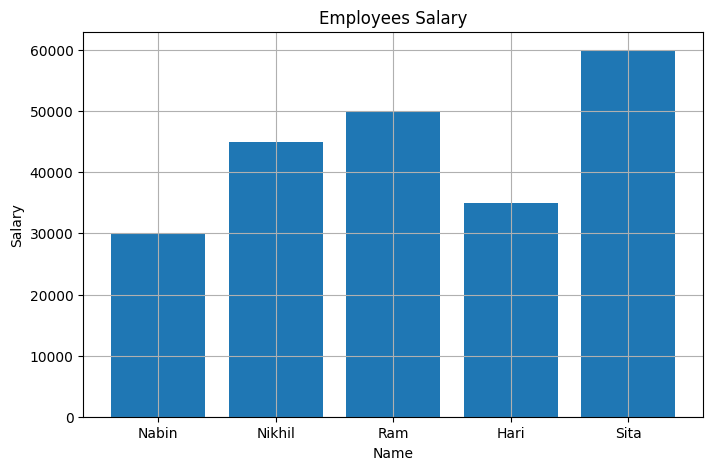

In [9]:
#Step 6 : Visualization
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.bar(
    df2["Name"],
    df2["Salary"]
)
plt.title("Employees Salary")
plt.xlabel("Name")
plt.ylabel("Salary")
plt.grid()
plt.show()
           

In [21]:
#Homework
import pandas as pd
df = pd.read_csv("Real_Data.CSV")
print(df)
print(df.shape)


    S.N.                         Asset Name  Market Type      Price Currency
0      1                      Bitcoin (BTC)       Crypto  63,563.66      USD
1      2                     Ethereum (ETH)       Crypto   1,688.58      USD
2      3                 Binance Coin (BNB)       Crypto     593.45      USD
3      4                       Solana (SOL)       Crypto      65.11      USD
4      5                       Ripple (XRP)       Crypto       1.16      USD
5      6                      Tether (USDT)       Crypto       0.99      USD
6      7                      Cardano (ADA)       Crypto       0.45      USD
7      8                    Dogecoin (DOGE)       Crypto       0.14      USD
8      9                   Shiba Inu (SHIB)       Crypto   0.000021      USD
9     10                   Avalanche (AVAX)       Crypto       32.5      USD
10    11             NABIL (Nabil Bank Ltd)  NEPSE Stock        533      USD
11    12                NTC (Nepal Telecom)  NEPSE Stock      853.5      USD

In [38]:
# remove ("," )
df["Price"] = df["Price"].replace(",","").astype(float)
print(df)

    S.N.                         Asset Name  Market Type         Price  \
0      1                      Bitcoin (BTC)       Crypto  63563.660000   
1      2                     Ethereum (ETH)       Crypto   1688.580000   
2      3                 Binance Coin (BNB)       Crypto    593.450000   
3      4                       Solana (SOL)       Crypto     65.110000   
4      5                       Ripple (XRP)       Crypto      1.160000   
5      6                      Tether (USDT)       Crypto      0.990000   
6      7                      Cardano (ADA)       Crypto      0.450000   
7      8                    Dogecoin (DOGE)       Crypto      0.140000   
8      9                   Shiba Inu (SHIB)       Crypto      0.000021   
9     10                   Avalanche (AVAX)       Crypto     32.500000   
10    11             NABIL (Nabil Bank Ltd)  NEPSE Stock    533.000000   
11    12                NTC (Nepal Telecom)  NEPSE Stock    853.500000   
12    13             EBL (Everest Bank

In [39]:

import sqlite3
conn = sqlite3.connect("real_data.db")
df.to_sql(
    "asset1",
    conn,
    if_exists="replace",
    index=False
)
conn.commit()
#checking data from sql
cursor = conn.cursor()
cursor.execute("SELECT * FROM asset1 LIMIT 5")
print(cursor.fetchall())

[(1, 'Bitcoin (BTC)', 'Crypto', 63563.66, 'USD'), (2, 'Ethereum (ETH)', 'Crypto', 1688.58, 'USD'), (3, 'Binance Coin (BNB)', 'Crypto', 593.45, 'USD'), (4, 'Solana (SOL)', 'Crypto', 65.11, 'USD'), (5, 'Ripple (XRP)', 'Crypto', 1.16, 'USD')]


In [40]:
# finding incloded data in sql
cursor.execute("""
SELECT name FROM sqlite_master WHERE type='table'""")
print(cursor.fetchall())
cursor.execute("SELECT COUNT(*) FROM asset1")
print(cursor.fetchall())


[('Asset',), ('asset1',)]
[(20,)]


In [41]:
df2 = pd.read_sql_query("SELECT * FROM asset1", conn)
print(df2)

    S.N.                         Asset Name  Market Type         Price  \
0      1                      Bitcoin (BTC)       Crypto  63563.660000   
1      2                     Ethereum (ETH)       Crypto   1688.580000   
2      3                 Binance Coin (BNB)       Crypto    593.450000   
3      4                       Solana (SOL)       Crypto     65.110000   
4      5                       Ripple (XRP)       Crypto      1.160000   
5      6                      Tether (USDT)       Crypto      0.990000   
6      7                      Cardano (ADA)       Crypto      0.450000   
7      8                    Dogecoin (DOGE)       Crypto      0.140000   
8      9                   Shiba Inu (SHIB)       Crypto      0.000021   
9     10                   Avalanche (AVAX)       Crypto     32.500000   
10    11             NABIL (Nabil Bank Ltd)  NEPSE Stock    533.000000   
11    12                NTC (Nepal Telecom)  NEPSE Stock    853.500000   
12    13             EBL (Everest Bank

In [42]:
# Highest Price in stock 
print("Max Price :\n", df2["Price"].max())

Max Price :
 63563.66


In [45]:
#Minimum Price
print("MINI Price :\n", df2["Price"].min())

MINI Price :
 2.1e-05


In [48]:
# Average Price
print("Average Price :\n", df2["Price"].mean())

Average Price :
 3617.72200105


In [50]:
#Top 1 price
print(df.loc[df["Price"].idxmax()])

S.N.                       1
Asset Name     Bitcoin (BTC)
Market Type           Crypto
Price               63563.66
Currency                 USD
Name: 0, dtype: object


In [52]:
# Top Lowest Price
print(df.loc[df["Price"].idxmin()])

S.N.                          9
Asset Name     Shiba Inu (SHIB)
Market Type              Crypto
Price                  0.000021
Currency                    USD
Name: 8, dtype: object


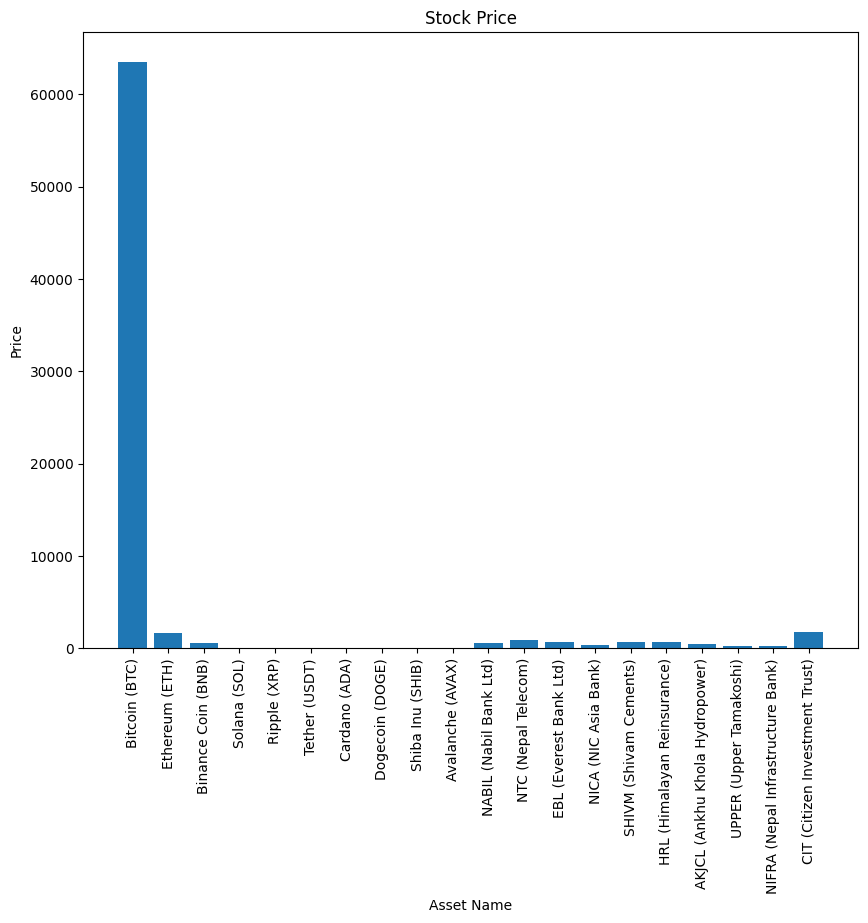

In [55]:
# Data Visualization
import matplotlib.pyplot as plt
plt.figure(figsize=(10,8))
plt.bar(
    df2["Asset Name"],
    df2["Price"]
)
plt.title("Stock Price")
plt.xlabel("Asset Name")
plt.ylabel("Price")
plt.xticks(rotation=90)
plt.show()

In [1]:
#Homework
import pandas as pd
df = pd.read_csv("employees.CSV")
print(df)

   ID    Name  Salary
0   1   Nabin   30000
1   2  Nikhil   45000
2   3     Ram   50000
3   4    Hari   35000
4   5    Sita   60000


In [3]:
#save into sql
import sqlite3
conn = sqlite3.connect("employees.db")
df.to_sql("employees.db",conn , if_exists="replace", index=False)
print("saved")

saved


In [4]:
#find query
df2 = pd.read_sql_query("SELECT *FROM employees",conn)
print(df2)

   ID    Name  Salary
0   1   Nabin   30000
1   2  Nikhil   45000
2   3     Ram   50000
3   4    Hari   35000
4   5    Sita   60000


In [9]:
#find max Salary
print("Max Salary:\n", df["Salary"].max())


Max Salary:
 60000


In [10]:
#Mini price
print("MINI Salary:\n", df["Salary"].min())

MINI Salary:
 30000


In [8]:
#Average Price
print("Average Price:\n", df["Salary"].mean())

Average Price:
 44000.0


In [15]:
#Top 1 salary detais
print("Top 1 Salary details:\n", df.loc[df["Salary"].idxmax()])

Top 1 Salary details:
 ID            5
Name       Sita
Salary    60000
Name: 4, dtype: object


In [14]:
#Lowest Price
print("Top 1 Lowest Salary details:\n",df.loc[df["Salary"].idxmin()])

Top 1 Lowest Salary details:
 ID            1
Name      Nabin
Salary    30000
Name: 0, dtype: object


   ID    Name  Salary
0   1   Nabin   30000
1   2  Nikhil   45000
2   3     Ram   50000
3   4    Hari   35000
4   5    Sita   60000
   ID    Name  Salary
0   1   Nabin   30000
1   2  Nikhil   45000
2   3     Ram   50000
3   4    Hari   35000
4   5    Sita   60000


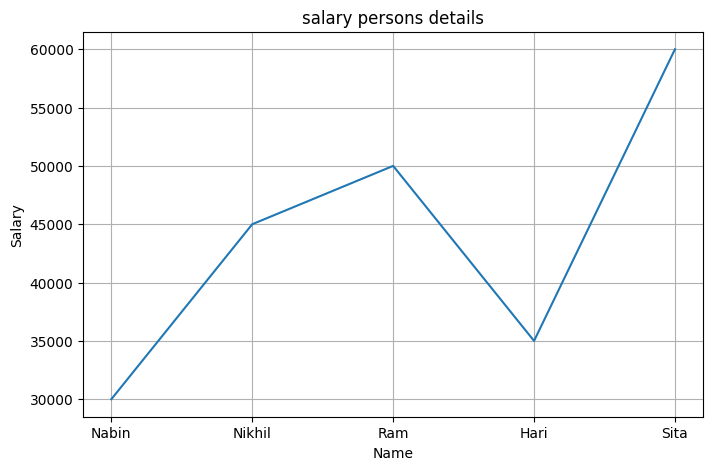

In [23]:
import pandas as pd
df = pd.read_csv("employees.CSV")
print(df)
import sqlite3
conn = sqlite3.connect("emp.db")
df.to_sql("emp", conn, if_exists="replace", index=False)
df2 = pd.read_sql_query("SELECT * FROM emp",conn)
print(df2)
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))

plt.plot(
    df["Name"],
    df["Salary"]
)
plt.title("salary persons details")
plt.xlabel("Name")
plt.ylabel("Salary")
plt.grid()
plt.show()